<a href="https://colab.research.google.com/github/saraswathi139/Machine-Learning-Lab/blob/main/ML_EXP_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
from sklearn.datasets import fetch_20newsgroups
import pandas as pd

data = fetch_20newsgroups(
    subset="train",
    remove=("headers", "footers", "quotes")
)

df = pd.DataFrame({
    "documents": data.data,
    "labels": data.target,
    "label_names": [data.target_names[i] for i in data.target]
})

df.to_csv("train_20newsgroups.csv", index=False)

print("Dataset created successfully!")
print(df.shape)
print(df.head())

Dataset created successfully!
(11314, 3)
                                           documents  labels  \
0  I was wondering if anyone out there could enli...       7   
1  A fair number of brave souls who upgraded thei...       4   
2  well folks, my mac plus finally gave up the gh...       4   
3  \nDo you have Weitek's address/phone number?  ...       1   
4  From article <C5owCB.n3p@world.std.com>, by to...      14   

             label_names  
0              rec.autos  
1  comp.sys.mac.hardware  
2  comp.sys.mac.hardware  
3          comp.graphics  
4              sci.space  


In [4]:
from sklearn.datasets import fetch_20newsgroups
import pandas as pd

data = fetch_20newsgroups(
    subset="test",
    remove=("headers", "footers", "quotes")
)

df_test = pd.DataFrame({
    "documents": data.data,
    "labels": data.target,
    "label_names": [data.target_names[i] for i in data.target]
})

df_test.to_csv("test_20newsgroups.csv", index=False)

print("Test dataset created successfully!")
print(df_test.shape)
print(df_test.head())

Test dataset created successfully!
(7532, 3)
                                           documents  labels  \
0  I am a little confused on all of the models of...       7   
1  I'm not familiar at all with the format of the...       5   
2                                \nIn a word, yes.\n       0   
3  \nThey were attacking the Iraqis to drive them...      17   
4  \nI've just spent two solid months arguing tha...      19   

             label_names  
0              rec.autos  
1         comp.windows.x  
2            alt.atheism  
3  talk.politics.mideast  
4     talk.religion.misc  


In [5]:
import pandas as pd

In [6]:
train_df = pd.read_csv("train_20newsgroups.csv")
test_df = pd.read_csv("test_20newsgroups.csv")

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)


Train Shape: (11314, 3)
Test Shape : (7532, 3)


In [7]:
print("Train Columns:")
print(train_df.columns)

print("\nTest Columns:")
print(test_df.columns)


Train Columns:
Index(['documents', 'labels', 'label_names'], dtype='object')

Test Columns:
Index(['documents', 'labels', 'label_names'], dtype='object')


In [8]:
train_df = train_df.dropna()
test_df = test_df.dropna()

print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

Train Shape: (11096, 3)
Test Shape : (7370, 3)


In [9]:
X_train = train_df["documents"]
y_train = train_df["labels"]

X_test = test_df["documents"]
y_test = test_df["labels"]

print("Training Documents:", len(X_train))
print("Testing Documents :", len(X_test))

Training Documents: 11096
Testing Documents : 7370


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF Shape:", X_train_tfidf.shape)
print("Testing TF-IDF Shape :", X_test_tfidf.shape)


Training TF-IDF Shape: (11096, 5000)
Testing TF-IDF Shape : (7370, 5000)


In [11]:
from sklearn.svm import SVC

model = SVC(kernel="linear")

print("SVM model created successfully!")

SVM model created successfully!


In [12]:
model.fit(X_train_tfidf, y_train)

print("SVM model trained successfully!")


SVM model trained successfully!


In [13]:
y_pred = model.predict(X_test_tfidf)

print("Prediction completed successfully!")
print("Predicted Labels:", y_pred[:20])

Prediction completed successfully!
Predicted Labels: [ 7  1 19 17  0 13  8  1  5  1  2  1 17  8 15  3  2  3  6 16]


In [14]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6359565807327001


In [15]:
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.40      0.49      0.44       313
           1       0.54      0.68      0.60       384
           2       0.62      0.61      0.61       382
           3       0.59      0.59      0.59       387
           4       0.70      0.62      0.66       374
           5       0.80      0.63      0.71       394
           6       0.76      0.75      0.75       388
           7       0.62      0.66      0.64       378
           8       0.52      0.72      0.61       392
           9       0.77      0.73      0.75       385
          10       0.88      0.80      0.84       392
          11       0.87      0.65      0.75       382
          12       0.50      0.54      0.52       383
          13       0.69      0.68      0.68       384
          14       0.65      0.68      0.67       383
          15       0.65      0.71      0.68       387
          16       0.53      0.63      0.58       356
   

In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[152   3   2   0   1   1   1   4   9   5   3   1   5   9  16  49  12   7
    7  26]
 [  4 260  26  11   5  24   5   6   7   3   0   3  15   3   9   1   0   1
    1   0]
 [  7  29 234  39  14  13   1   2   9   2   1   4   4   8   9   0   1   0
    2   3]
 [  0  22  41 230  30   5  14   4   2   3   0   3  27   1   1   0   3   0
    0   1]
 [  2  16  11  42 233   1  11   7   8   2   3   2  25   2   6   1   2   0
    0   0]
 [  0  61  35  11   3 250   4   2  10   1   0   3   7   4   1   0   1   1
    0   0]
 [  0   1   3  20  17   0 292  11  14   2   1   1  10   2   6   1   3   1
    2   1]
 [  8   4   1   2   3   3  12 251  36   3   2   1  21   5   8   0   6   1
    9   2]
 [  8   3   0   1   2   1   5  37 283   7   1   0  10   6   9   2   9   0
    7   1]
 [  5   6   0   2   2   0   6   8  19 280  23   1   4   5   4   2   4   4
    8   2]
 [  5   2   2   1   1   1   2   2  15  23 315   0   3   3   5   0   8   1
    2   1]
 [  4  12   5   4   4   2   6   5   9   3   3 2

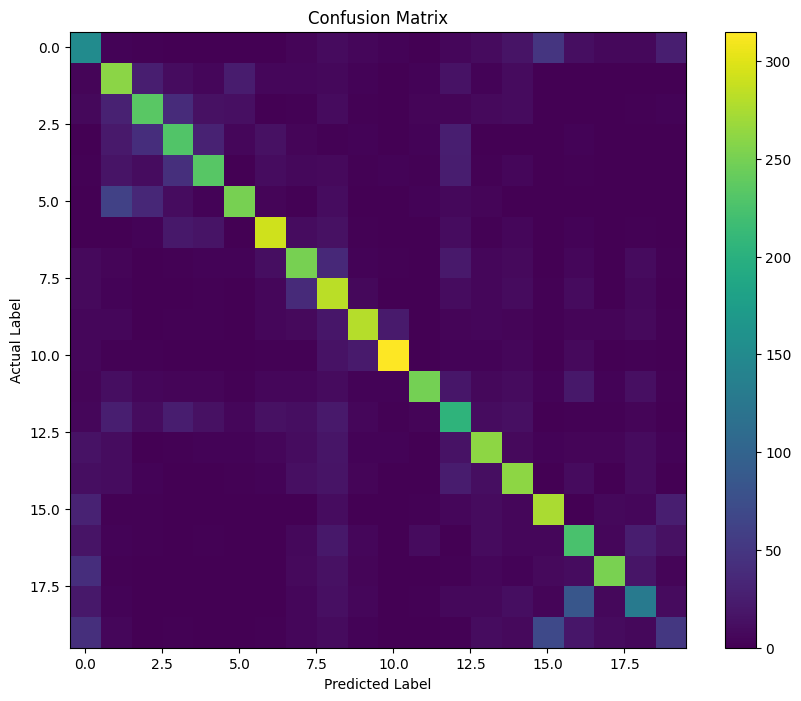

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.colorbar()
plt.show()
